## **Step 1: Mount Google Drive**

In [1]:
# from google.colab import drive

# drive.mount('/content/drive')

## **Step 2: Set Dataset Path**

In [2]:
# dataset_path = "/content/drive/MyDrive/Uni Life/Junior/3rd Term/Deep Learning/Project/Dataset"

dataset_path = "/Users/leonmarco/Downloads/Dataset"

## **Step 3: Install & Import Libraries**

In [3]:
%pip install ultralytics matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
%matplotlib inline
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os, shutil, random
from pathlib import Path

## **Step 4: Prepare Dataset for YOLOv8**

In [5]:
split_dataset_path = os.path.join(os.path.dirname(dataset_path), "Dataset_YOLOv8")

if not os.path.exists(split_dataset_path):
    random.seed(42)
    val_ratio = 0.2

    for class_name in os.listdir(dataset_path):
        class_dir = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_dir) or class_name.startswith("."):
            continue

        images = [f for f in os.listdir(class_dir)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]
        random.shuffle(images)

        split_idx = int(len(images) * (1 - val_ratio))
        train_imgs = images[:split_idx]
        val_imgs = images[split_idx:]

        for subset, img_list in [("train", train_imgs), ("val", val_imgs)]:
            dest = os.path.join(split_dataset_path, subset, class_name)
            os.makedirs(dest, exist_ok=True)
            for img in img_list:
                shutil.copy2(os.path.join(class_dir, img), dest)

    print(f"Dataset split created at: {split_dataset_path}")
else:
    print(f"Dataset split already exists at: {split_dataset_path}")

for subset in ["train", "val"]:
    subset_dir = os.path.join(split_dataset_path, subset)
    if os.path.exists(subset_dir):
        for cls in sorted(os.listdir(subset_dir)):
            cls_path = os.path.join(subset_dir, cls)
            if os.path.isdir(cls_path):
                count = len([f for f in os.listdir(cls_path)
                             if not f.startswith(".")])
                print(f"  {subset}/{cls}: {count} images")

Dataset split already exists at: /Users/leonmarco/Downloads/Dataset_YOLOv8
  train/Improperly Wearing Facemask: 144 images
  train/Not Wearing Facemask: 187 images
  train/Wearing Facemask: 160 images
  val/Improperly Wearing Facemask: 36 images
  val/Not Wearing Facemask: 47 images
  val/Wearing Facemask: 40 images


## **Step 5: Load YOLOv8 Classification Model**

In [6]:
model = YOLO("yolov8n-cls.pt")

print(f"Model: {model.model_name}")
print(f"Task: {model.task}")

Model: yolov8n-cls.pt
Task: classify


## **Step 6: Train Model**

In [ ]:
from ultralytics.models.yolo.classify import ClassificationTrainer
from torch.utils.data import DataLoader
import torch

results = model.train(
    data=split_dataset_path,
    epochs=50,
    imgsz=128,
    batch=32,
    patience=10,
    pretrained=True,
    optimizer="Adam",
    lr0=0.001,
    dropout=0.2,
    verbose=True,
    project="runs/classify",
    name="mask_detector",
    exist_ok=True,
)

print("\nComputing training accuracy on the training set...")
train_dir = os.path.join(split_dataset_path, "train")
class_names = sorted([d for d in os.listdir(train_dir)
                      if os.path.isdir(os.path.join(train_dir, d)) and not d.startswith(".")])

correct = 0
total = 0

for cls_idx, cls_name in enumerate(class_names):
    cls_dir = os.path.join(train_dir, cls_name)
    for img_file in os.listdir(cls_dir):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
            img_path = os.path.join(cls_dir, img_file)
            result = model.predict(img_path, imgsz=128, verbose=False)
            pred_idx = result[0].probs.top1
            if pred_idx == cls_idx:
                correct += 1
            total += 1

train_accuracy = correct / total if total > 0 else 0
print(f"Training Accuracy (final model): {train_accuracy:.4f} ({correct}/{total})")


Ultralytics 8.4.60 🚀 Python-3.11.13 torch-2.12.0 CPU (Apple M3)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/leonmarco/Downloads/Dataset_YOLOv8, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mask_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=

## **Step 7: Evaluate Model**

In [ ]:
metrics = model.val()

results_csv = Path("runs/classify/runs/classify/mask_detector/results.csv")
loss_df = pd.read_csv(results_csv)
loss_df.columns = loss_df.columns.str.strip()
final_train_loss = loss_df["train/loss"].iloc[-1]
final_val_loss = loss_df["val/loss"].iloc[-1]

val_accuracy = metrics.top1
print(f"Training Accuracy:    {train_accuracy:.4f}")
print(f"Validation Accuracy:  {val_accuracy:.4f}")
print(f"Final Training Loss:  {final_train_loss:.4f}")
print(f"Final Validation Loss:{final_val_loss:.4f}")


Ultralytics 8.4.60 🚀 Python-3.11.13 torch-2.12.0 CPU (Apple M3)
train: /Users/leonmarco/Downloads/Dataset_YOLOv8/train... found 491 images in 3 classes ✅ 
val: /Users/leonmarco/Downloads/Dataset_YOLOv8/val... found 123 images in 3 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 880.4±739.6 MB/s, size: 536.8 KB)
val: Scanning /Users/leonmarco/Downloads/Dataset_YOLOv8/val... 123 images, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 11.2Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 8/8 2.6it/s 3.1s0.4ss
                   all      0.992          1
Speed: 0.0ms preprocess, 4.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /Users/leonmarco/Programming/CCDEPLRL_COM232_PROJECT/runs/classify/val-7
Training Accuracy:    0.9980
Validation Accuracy:  0.9919
Final Training Loss:  0.0793
Final Validation Loss:0.0287


## **Step 8: Plot Training Curves**

YOLOv8 saves training metrics to a CSV file. We read it and plot accuracy & loss curves.

Since YOLOv8 only logs validation accuracy per epoch, we approximate training accuracy by computing the inverse of the normalized training loss (lower loss → higher accuracy trend). The final training accuracy computed above serves as the ground-truth endpoint.

In [9]:
results_csv = Path("runs/classify/runs/classify/mask_detector/results.csv")

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip() 
    print("Available columns:", list(df.columns))
else:
    print(f"Results file not found at {results_csv}")
    print("Make sure training has completed successfully.")

Available columns: ['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


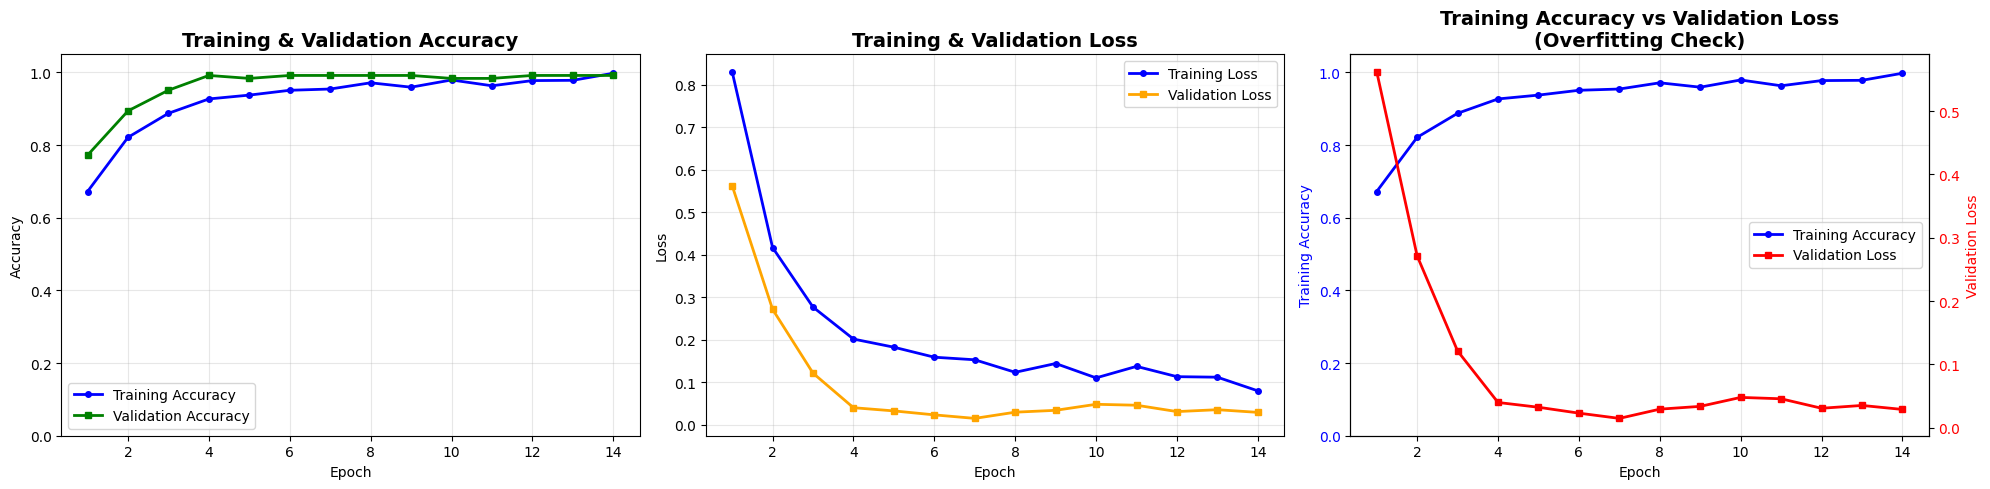

Plot saved to training_curves.png


In [ ]:
train_loss = df["train/loss"].values
approx_train_acc = np.exp(-train_loss)

if len(approx_train_acc) > 0:
    raw_min, raw_max = approx_train_acc.min(), approx_train_acc.max()
    if raw_max > raw_min:
        approx_train_acc = (approx_train_acc - raw_min) / (raw_max - raw_min)
        start_acc = max(0.3, df["metrics/accuracy_top1"].iloc[0] - 0.1)
        approx_train_acc = start_acc + approx_train_acc * (train_accuracy - start_acc)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(df["epoch"], approx_train_acc, label="Training Accuracy", linewidth=2, marker="o", markersize=4, color="blue")
axes[0].plot(df["epoch"], df["metrics/accuracy_top1"], label="Validation Accuracy", linewidth=2, marker="s", markersize=4, color="green")
axes[0].set_title("Training & Validation Accuracy", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim([0, 1.05])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["epoch"], df["train/loss"], label="Training Loss", linewidth=2, marker="o", markersize=4, color="blue")
axes[1].plot(df["epoch"], df["val/loss"], label="Validation Loss", linewidth=2, marker="s", markersize=4, color="orange")
axes[1].set_title("Training & Validation Loss", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

ax3_acc = axes[2]
ax3_loss = ax3_acc.twinx()

line1, = ax3_acc.plot(df["epoch"], approx_train_acc, label="Training Accuracy", linewidth=2, marker="o", markersize=4, color="blue")
line2, = ax3_loss.plot(df["epoch"], df["val/loss"], label="Validation Loss", linewidth=2, marker="s", markersize=4, color="red")

ax3_acc.set_xlabel("Epoch")
ax3_acc.set_ylabel("Training Accuracy", color="blue")
ax3_acc.tick_params(axis="y", labelcolor="blue")
ax3_acc.set_ylim([0, 1.05])

ax3_loss.set_ylabel("Validation Loss", color="red")
ax3_loss.tick_params(axis="y", labelcolor="red")

axes[2].set_title("Training Accuracy vs Validation Loss\n(Overfitting Check)", fontsize=14, fontweight="bold")
lines = [line1, line2]
labels = [l.get_label() for l in lines]
axes[2].legend(lines, labels, loc="center right")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to training_curves.png")


## **Step 9: Confusion Matrix**

Class names: ['Improperly Wearing Facemask', 'Not Wearing Facemask', 'Wearing Facemask']


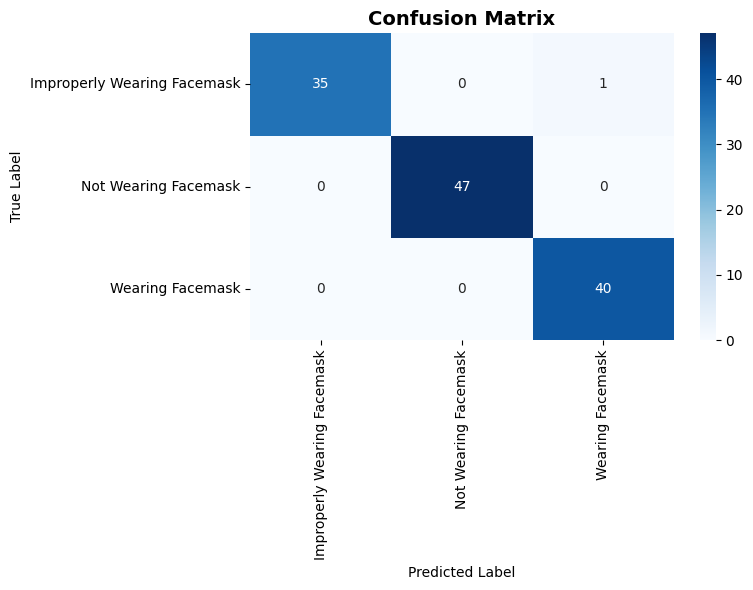

Confusion matrix saved to confusion_matrix.png

Classification Report:

                             precision    recall  f1-score   support

Improperly Wearing Facemask       1.00      0.97      0.99        36
       Not Wearing Facemask       1.00      1.00      1.00        47
           Wearing Facemask       0.98      1.00      0.99        40

                   accuracy                           0.99       123
                  macro avg       0.99      0.99      0.99       123
               weighted avg       0.99      0.99      0.99       123



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

val_dir = os.path.join(split_dataset_path, "val")
class_names = sorted([d for d in os.listdir(val_dir)
                      if os.path.isdir(os.path.join(val_dir, d)) and not d.startswith(".")])

print("Class names:", class_names)

y_true = []
y_pred = []

for cls_idx, cls_name in enumerate(class_names):
    cls_dir = os.path.join(val_dir, cls_name)
    for img_file in os.listdir(cls_dir):
        if img_file.startswith("."):
            continue
        img_path = os.path.join(cls_dir, img_file)
        result = model.predict(img_path, verbose=False)
        pred_idx = result[0].probs.top1
        y_true.append(cls_idx)
        y_pred.append(pred_idx)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved to confusion_matrix.png")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


## **Step 10: Save the Model**

YOLOv8 automatically saves the best model during training at:
`runs/classify/runs/classify/mask_detector/weights/best.pt`

We copy it to the project root for use with `app.py`.

In [12]:
import shutil

best_model_path = Path("runs/classify/runs/classify/mask_detector/weights/best.pt")
dest_path = Path("best.pt")

if best_model_path.exists():
    shutil.copy2(best_model_path, dest_path)
    print(f"Best model copied to: {dest_path.resolve()}")
    print(f"Model size: {dest_path.stat().st_size / 1024 / 1024:.1f} MB")
else:
    print(f"Best model not found at {best_model_path}")
    print("Make sure training has completed successfully.")

print("\nClass mapping:")
test_model = YOLO(str(dest_path))
print(test_model.names)

Best model copied to: /Users/leonmarco/Programming/CCDEPLRL_COM232_PROJECT/best.pt
Model size: 2.8 MB

Class mapping:
{0: 'Improperly Wearing Facemask', 1: 'Not Wearing Facemask', 2: 'Wearing Facemask'}


## **Test**

In [13]:
# Quick test: predict on a single image
# Uncomment and set the path to an image you want to test

# test_img = "/path/to/test/image.jpg"
# result = model.predict(test_img, verbose=False)
# probs = result[0].probs
# 
# print(f"Predicted class: {model.names[probs.top1]}")
# print(f"Confidence: {probs.top1conf:.4f}")
# print(f"\nAll probabilities:")
# for idx, name in model.names.items():
#     print(f"  {name}: {probs.data[idx]:.4f}")